# Task 2 — Trends and the spaghetti problem (`gapminder.csv`)

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,
                     "axes.titlesize":13,"axes.titleweight":"bold","axes.titlelocation":"left"})
NOTE = lambda fig, s: fig.text(0.01, -0.02, s, fontsize=9, color="dimgray", ha="left")   # exclusions / assumptions on the chart
df = pd.read_csv("gapminder.csv")
print(df.shape, df.country.nunique(), "countries", df.year.min(), "-", df.year.max(), "| missing:", int(df.isna().sum().sum()))
CONT = {"Africa":"#d62728","Americas":"#2ca02c","Asia":"#ff7f0e","Europe":"#1f77b4","Oceania":"#9467bd"}

(1704, 6) 142 countries 1952 - 2007 | missing: 0


## 1. The messy chart (on purpose)

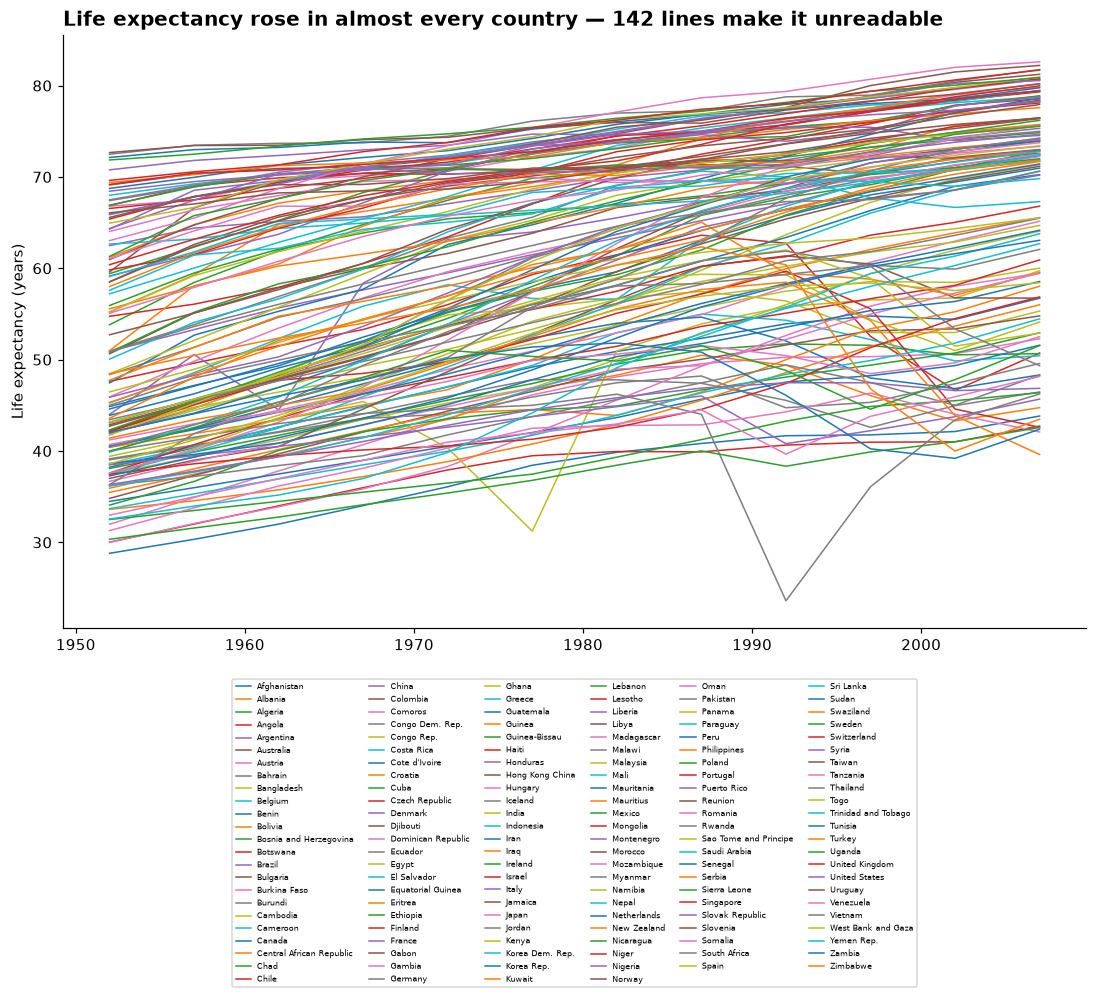

In [2]:
fig, ax = plt.subplots(figsize=(12, 7))
for c, d in df.groupby("country"): ax.plot(d.year, d.lifeExp, label=c, lw=1)
ax.legend(ncol=6, fontsize=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.set_title("Life expectancy rose in almost every country — 142 lines make it unreadable"); ax.set_ylabel("Life expectancy (years)"); plt.show()

**What is wrong with it**
- Over-plotting: 142 lines overlap into a band; no individual line can be followed.
- The legend has 142 entries in tiny type; a colour cannot be matched to a country because the default palette repeats.
- Colour carries no meaning (the colours are arbitrary and repeat).
- Interesting exceptions (e.g. a sudden dip) are buried in the crowd.
- Nothing is labelled or compared; the reader cannot tell which group (continent) is doing what.
- The title as written by default would only name the axes; it must state a finding.

## 2a. Aggregate — one line per continent
Assumption: unweighted mean of the countries in each continent (not population-weighted).

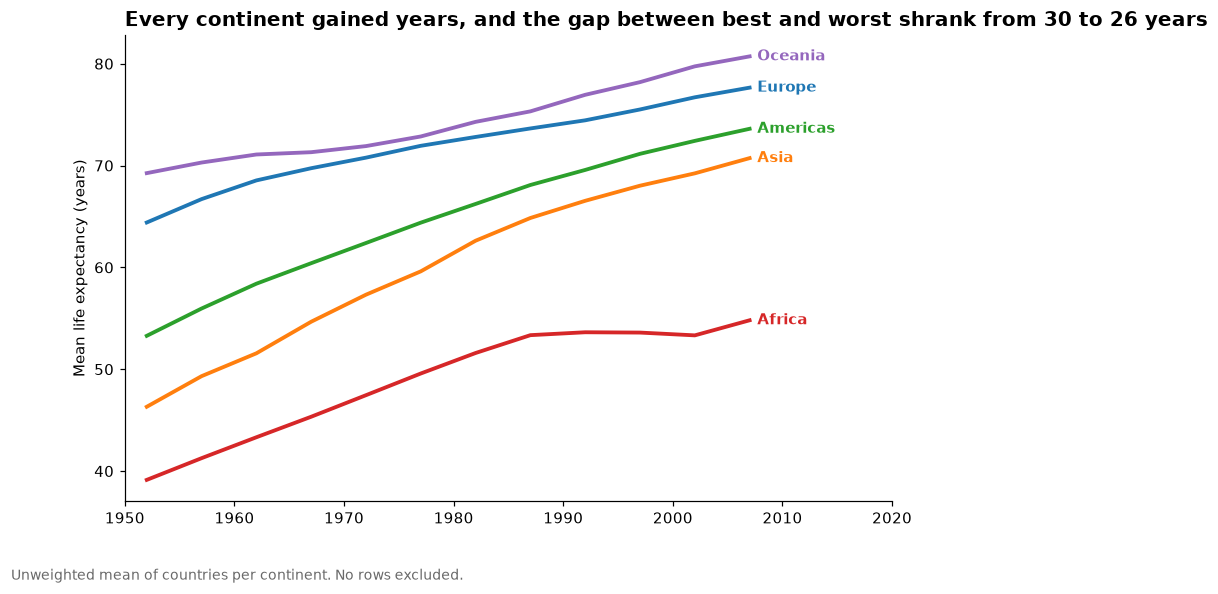

In [3]:
cont = df.groupby(["year","continent"]).lifeExp.mean().unstack()
fig, ax = plt.subplots(figsize=(9, 5.5))
for c in cont: 
    ax.plot(cont.index, cont[c], color=CONT[c], lw=2.5); ax.text(cont.index[-1]+0.7, cont[c].iloc[-1], c, color=CONT[c], va="center", fontweight="bold")
ax.set_xlim(1950, 2020); ax.set_ylabel("Mean life expectancy (years)")
gap0 = cont.loc[1952].max()-cont.loc[1952].min(); gap1 = cont.loc[2007].max()-cont.loc[2007].min()
ax.set_title(f"Every continent gained years, and the gap between best and worst shrank from {gap0:.0f} to {gap1:.0f} years")
NOTE(fig, "Unweighted mean of countries per continent. No rows excluded."); plt.show()

## 2b. Highlight — all 142 lines grey, 3 countries coloured and labelled

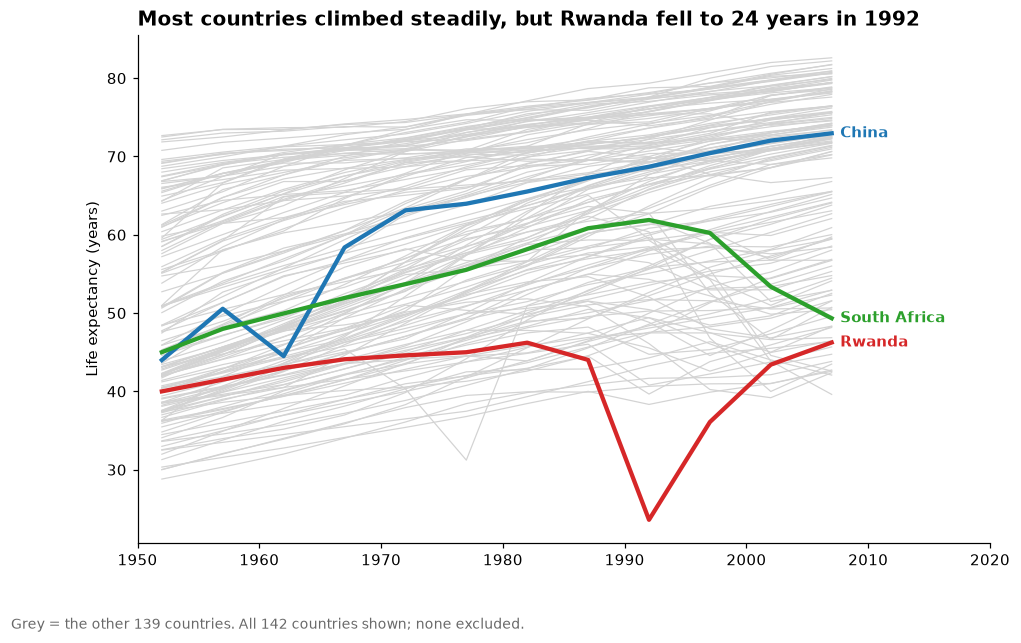

In [4]:
picks = {"Rwanda":"#d62728", "China":"#1f77b4", "South Africa":"#2ca02c"}   # chosen: genocide dip, post-famine recovery, HIV-era fall
fig, ax = plt.subplots(figsize=(10, 6))
for c, d in df.groupby("country"):
    if c not in picks: ax.plot(d.year, d.lifeExp, color="lightgrey", lw=0.8, zorder=1)
for c, col in picks.items():
    d = df[df.country == c]; ax.plot(d.year, d.lifeExp, color=col, lw=2.8, zorder=3)
    ax.text(d.year.iloc[-1]+0.7, d.lifeExp.iloc[-1], c, color=col, va="center", fontweight="bold")
ax.set_xlim(1950, 2020); ax.set_ylabel("Life expectancy (years)")
r = df[df.country=="Rwanda"].set_index("year").lifeExp; dip = r.diff().idxmin()
ax.set_title(f"Most countries climbed steadily, but Rwanda fell to {r.loc[dip]:.0f} years in {dip}")
NOTE(fig, "Grey = the other 139 countries. All 142 countries shown; none excluded."); plt.show()

## Comparing (a) and (b)
- **(a) Aggregate** shows the typical path and the comparison between groups, and the narrowing gap between continents. It cannot show any individual country, and averages hide spread and exceptions (a country can collapse without moving the average).
- **(b) Highlight** shows the exceptions and the full spread of countries, and keeps every country visible as context. It cannot summarise group differences and the story depends on which 3 countries I picked.

## 3. Has the gap between the richest and poorest countries narrowed since 1952?
**Histogram of `gdpPercap` first: linear vs log scale**

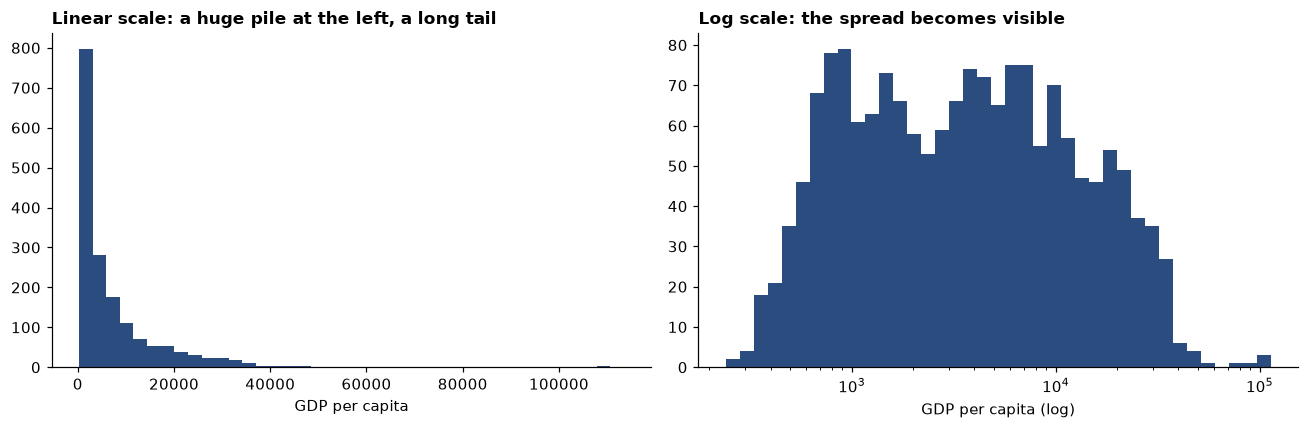

skew: 3.85 | log10 skew: 0.11


In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(df.gdpPercap, bins=40, color="#2b4c7e"); axs[0].set_title("Linear scale: a huge pile at the left, a long tail", fontsize=11); axs[0].set_xlabel("GDP per capita")
axs[1].hist(df.gdpPercap, bins=np.logspace(np.log10(df.gdpPercap.min()), np.log10(df.gdpPercap.max()), 40), color="#2b4c7e")
axs[1].set_xscale("log"); axs[1].set_title("Log scale: the spread becomes visible", fontsize=11); axs[1].set_xlabel("GDP per capita (log)")
fig.tight_layout(); plt.show()
print("skew:", round(df.gdpPercap.skew(), 2), "| log10 skew:", round(np.log10(df.gdpPercap).skew(), 2))

**Decision:** use a log scale. `gdpPercap` is strongly right-skewed, so on a linear axis most countries are squashed against the left or bottom and only the richest are visible. A log axis gives equal space to equal *multiples* (doubling), which is what "gap between rich and poor" means as a ratio.

,poorest10,richest10,ratio,abs_gap
year,,,,
1952,495.0,7255.3,14.7,6760.3
1957,576.0,9667.9,16.8,9091.8
1962,603.1,10967.2,18.2,10364.1
1967,701.6,14060.6,20.0,13359.0
1972,724.1,16606.2,22.9,15882.1
1977,741.5,19091.7,25.7,18350.3
1982,789.7,19467.7,24.7,18678.0
1987,738.0,21866.5,29.6,21128.5
1992,737.3,24752.2,33.6,24015.0


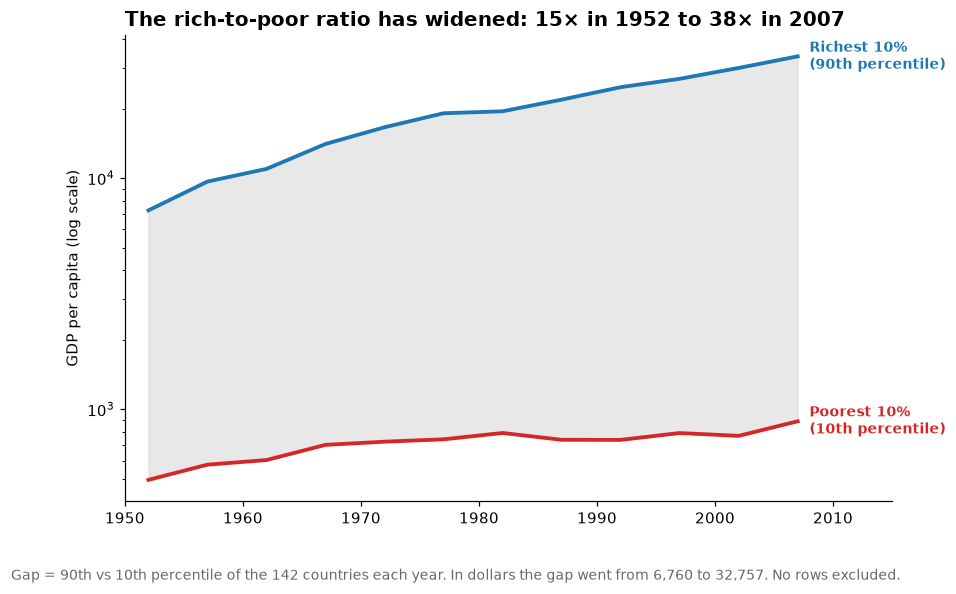

In [6]:
yrs = sorted(df.year.unique())
p = df.groupby("year").gdpPercap.quantile([0.1, 0.9]).unstack(); p.columns = ["poorest10","richest10"]
p["ratio"] = p.richest10/p.poorest10; p["abs_gap"] = p.richest10-p.poorest10
display(p.round(1))
r0, r1 = p.ratio.iloc[0], p.ratio.iloc[-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(p.index, p.richest10, color="#1f77b4", lw=2.5); ax.plot(p.index, p.poorest10, color="#d62728", lw=2.5)
ax.fill_between(p.index, p.poorest10, p.richest10, color="lightgrey", alpha=0.5)
ax.set_yscale("log"); ax.set_xlim(1950, 2015); ax.set_ylabel("GDP per capita (log scale)")
ax.text(2008, p.richest10.iloc[-1], "Richest 10%\n(90th percentile)", color="#1f77b4", va="center", fontsize=9, fontweight="bold")
ax.text(2008, p.poorest10.iloc[-1], "Poorest 10%\n(10th percentile)", color="#d62728", va="center", fontsize=9, fontweight="bold")
word = "narrowed" if r1 < r0 else "widened"
ax.set_title(f"The rich-to-poor ratio has {word}: {r0:.0f}× in 1952 to {r1:.0f}× in 2007")
NOTE(fig, f"Gap = 90th vs 10th percentile of the 142 countries each year. In dollars the gap went from {p.abs_gap.iloc[0]:,.0f} to {p.abs_gap.iloc[-1]:,.0f}. No rows excluded."); plt.show()

**Why this chart:** a two-line chart over time with the area between the lines shaded, because the question is about a *gap over time*. A log axis makes the vertical distance equal the ratio. Percentiles (10th/90th) are used instead of the single richest and poorest countries, so one oil state or one war does not decide the answer. Assumption: "richest and poorest" is measured by GDP per capita.
The title reports the ratio; the dollar gap is given in the footnote because the answer differs depending on whether the gap is measured as a ratio or in absolute dollars.